# Vigia Recife

## Plataforma de Inteligência Urbana para Análise da Violência no Recife

---

## Objetivo

O **Vigia Recife** é uma plataforma de Inteligência Urbana desenvolvida para analisar padrões espaciais, temporais e estatísticos da violência na cidade do Recife.

O projeto utiliza técnicas de Ciência de Dados para transformar dados públicos em informações estratégicas que possam apoiar a tomada de decisão na gestão da segurança pública.

Ao longo deste notebook são realizadas as etapas de:

- Importação e exploração dos dados;
- Limpeza e tratamento da base;
- Engenharia de atributos;
- Estatística descritiva;
- Análise exploratória dos dados (EDA);
- Visualizações geográficas e temporais;
- Clusterização de bairros;
- Séries temporais;
- Construção de indicadores estratégicos (KPIs);
- Geração de insights para apoio à gestão pública.

# 1. Importação das Bibliotecas

Nesta etapa são importadas todas as bibliotecas utilizadas durante o desenvolvimento do projeto.

Os imports permanecem centralizados nesta única célula para facilitar manutenção e reprodutibilidade.

In [ ]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import folium

from folium.plugins import HeatMap

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.stats import linregress

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving csv - eventos.csv to csv - eventos.csv


In [ ]:
plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="Reds"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

# 2. Leitura da Base de Dados

Nesta etapa é realizado apenas o carregamento da base original.

A variável **df** representa a base bruta, sem qualquer tipo de modificação ou tratamento.

In [ ]:
df = pd.read_csv("csv - eventos.csv")

df.head()

,id,address,region,state,city,neighborhood,sub_neighborhood,locality,latitude,longitude,...,place,serviceStatus,qualifications,politicalPosition,politicalStatus,partie,coorporation,agentPosition,agentStatus,unit
0,12667,"R. Cel. Fernando Machado - Jardim São Paulo, R...",Nordeste,Pernambuco,Recife,JARDIM SAO PAULO,NaN,COMUNIDADE DO INFERNINHO,-8.075492,-34.937383,...,sem identificação,não se aplica,PPTE,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
1,12667,"R. Cel. Fernando Machado - Jardim São Paulo, R...",Nordeste,Pernambuco,Recife,JARDIM SAO PAULO,NaN,COMUNIDADE DO INFERNINHO,-8.075492,-34.937383,...,sem identificação,não se aplica,NaN,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
2,12759,"Ibura, Recife - PE, Brasil",Nordeste,Pernambuco,Recife,IBURA,NaN,UR 10,-8.110156,-34.936597,...,automóvel,não se aplica,NaN,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
3,12906,"Praça do Jardim São Paulo - Jardim São Paulo, ...",Nordeste,Pernambuco,Recife,JARDIM SAO PAULO,NaN,NaN,-8.081632,-34.938355,...,sem identificação,não se aplica,Agente de segurança,não se aplica,não se aplica,NaN,polícia penal,não identificado,fora de serviço,NaN
4,12756,Segundo jardim de boa viagem,Nordeste,Pernambuco,Recife,BOA VIAGEM,NaN,NaN,-8.105009,-34.886986,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Conhecendo a Base de Dados

Antes de qualquer tratamento é importante compreender a estrutura da base.

Nesta etapa são analisadas:

- primeiras linhas;
- dimensões;
- tipos de dados;
- valores ausentes;
- estatísticas descritivas;
- variáveis categóricas.

In [ ]:
df.head()

,id,address,region,state,city,neighborhood,sub_neighborhood,locality,latitude,longitude,...,place,serviceStatus,qualifications,politicalPosition,politicalStatus,partie,coorporation,agentPosition,agentStatus,unit
0,12667,"R. Cel. Fernando Machado - Jardim São Paulo, R...",Nordeste,Pernambuco,Recife,JARDIM SAO PAULO,NaN,COMUNIDADE DO INFERNINHO,-8.075492,-34.937383,...,sem identificação,não se aplica,PPTE,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
1,12667,"R. Cel. Fernando Machado - Jardim São Paulo, R...",Nordeste,Pernambuco,Recife,JARDIM SAO PAULO,NaN,COMUNIDADE DO INFERNINHO,-8.075492,-34.937383,...,sem identificação,não se aplica,NaN,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
2,12759,"Ibura, Recife - PE, Brasil",Nordeste,Pernambuco,Recife,IBURA,NaN,UR 10,-8.110156,-34.936597,...,automóvel,não se aplica,NaN,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
3,12906,"Praça do Jardim São Paulo - Jardim São Paulo, ...",Nordeste,Pernambuco,Recife,JARDIM SAO PAULO,NaN,NaN,-8.081632,-34.938355,...,sem identificação,não se aplica,Agente de segurança,não se aplica,não se aplica,NaN,polícia penal,não identificado,fora de serviço,NaN
4,12756,Segundo jardim de boa viagem,Nordeste,Pernambuco,Recife,BOA VIAGEM,NaN,NaN,-8.105009,-34.886986,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,id,address,region,state,city,neighborhood,sub_neighborhood,locality,latitude,longitude,...,place,serviceStatus,qualifications,politicalPosition,politicalStatus,partie,coorporation,agentPosition,agentStatus,unit
5884,78206,Conjunto Habitacional do Cordeiro - R. Odete M...,Nordeste,Pernambuco,Recife,CORDEIRO,NaN,CONJUNTO HABITACIONAL DO CORDEIRO,-8.045305,-34.921479,...,sem identificação,não se aplica,PPTE,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
5885,78208,"Viashow - Avenida Aníbal Benévolo - Água Fria,...",Nordeste,Pernambuco,Recife,AGUA FRIA,NaN,NaN,-8.007744,-34.895353,...,sem identificação,não se aplica,Não identificado,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
5886,78210,Córrego do marreco - R. Córrego do Marreco - C...,Nordeste,Pernambuco,Recife,CORREGO DO JENIPAPO,NaN,NaN,-7.996338,-34.937854,...,residência,não se aplica,PPTE,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
5887,78209,"R. Padre Carapuceiro - Boa Viagem, Recife - PE...",Nordeste,Pernambuco,Recife,BOA VIAGEM,NaN,NaN,-8.118050,-34.899440,...,sem identificação,não se aplica,Não identificado,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN
5888,78220,"Jardim Uchoa - Rua Valdemir Téles - Areias, Re...",Nordeste,Pernambuco,Recife,AREIAS,NaN,JARDIM UCHOA,-8.102344,-34.936865,...,residência,não se aplica,Não identificado,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,NaN


In [ ]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

Linhas: 5889
Colunas: 38


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5889 entries, 0 to 5888
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5889 non-null   int64  
 1   address               5889 non-null   object 
 2   region                5889 non-null   object 
 3   state                 5889 non-null   object 
 4   city                  5889 non-null   object 
 5   neighborhood          5889 non-null   object 
 6   sub_neighborhood      37 non-null     object 
 7   locality              1409 non-null   object 
 8   latitude              5889 non-null   float64
 9   longitude             5889 non-null   float64
 10  data                  5889 non-null   object 
 11  police_action         5889 non-null   bool   
 12  agent_presence        5889 non-null   bool   
 13  police_unit           340 non-null    object 
 14  main_reason           5889 non-null   object 
 15  complementary_reason 

In [ ]:
df.describe()

,id,latitude,longitude,complementary_reason,age,partie
count,5889.000000,5889.000000,5889.000000,0.0,4083.000000,0.0
mean,49789.056886,-8.054849,-34.921455,NaN,29.221406,NaN
std,17257.656022,0.041900,0.024245,NaN,10.779422,NaN
min,12667.000000,-8.152800,-34.993871,NaN,1.000000,NaN
25%,37138.000000,-8.085702,-34.937197,NaN,22.000000,NaN
50%,50112.000000,-8.057944,-34.921666,NaN,27.000000,NaN
75%,63817.000000,-8.018023,-34.903381,NaN,35.000000,NaN
max,78220.000000,-7.932411,-34.869131,NaN,80.000000,NaN


In [ ]:
df.describe(include="all")

,id,address,region,state,city,neighborhood,sub_neighborhood,locality,latitude,longitude,...,place,serviceStatus,qualifications,politicalPosition,politicalStatus,partie,coorporation,agentPosition,agentStatus,unit
count,5889.000000,5889,5889,5889,5889,5889,37,1409,5889.000000,5889.000000,...,5562,5562,3333,5562,5562,0.0,5562,5562,5562,28
unique,NaN,3999,1,1,1,91,6,229,NaN,NaN,...,12,4,41,2,2,NaN,10,13,5,22
top,NaN,"Ibura, Recife - PE, Brasil",Nordeste,Pernambuco,Recife,IBURA,UR 07,COMUNIDADE DO BODE,NaN,NaN,...,sem identificação,não se aplica,Não identificado,não se aplica,não se aplica,NaN,não se aplica,não se aplica,não se aplica,19º batalhão
freq,NaN,48,5889,5889,5889,230,21,80,NaN,NaN,...,4413,5132,2053,5561,5561,NaN,5480,5480,5480,5
mean,49789.056886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.054849,-34.921455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,17257.656022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.041900,0.024245,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,12667.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.152800,-34.993871,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,37138.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.085702,-34.937197,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,50112.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.057944,-34.921666,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,63817.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.018023,-34.903381,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.dtypes

,0
id,int64
address,object
region,object
state,object
city,object
neighborhood,object
sub_neighborhood,object
locality,object
latitude,float64
longitude,float64


In [ ]:
# Quantidade de valores ausentes
df.isna().sum().sort_values(ascending=False)

,0
partie,5889
complementary_reason,5889
unit,5861
sub_neighborhood,5852
police_unit,5549
clippings,5450
locality,4480
circumstances,2889
qualifications,2556
age,1806


In [ ]:
# Valores únicos por coluna categórica
colunas_categoricas = df.select_dtypes(include="object").columns

for coluna in colunas_categoricas:

    print("=" * 60)
    print(coluna)
    print("=" * 60)

    print(df[coluna].nunique())

address
3999
region
1
state
1
city
1
neighborhood
91
sub_neighborhood
6
locality
229
data
3366
police_unit
67
main_reason
16
clippings
24
id_victim
5562
type
1
situation
2
circumstances
7
deathDate
2542
personType
2
ageGroup
5
genre
5
race
5
place
12
serviceStatus
4
qualifications
41
politicalPosition
2
politicalStatus
2
coorporation
10
agentPosition
13
agentStatus
5
unit
22


## Considerações Iniciais

A exploração inicial da base permite compreender sua estrutura e identificar possíveis problemas de qualidade dos dados, como valores ausentes, inconsistências de preenchimento e diferenças de padronização entre registros.

Essas observações servirão como base para as etapas de limpeza e tratamento apresentadas nas próximas seções.

# 4. Limpeza da Base de Dados

Nesta etapa é criada uma única cópia da base original denominada **df_limpo**.

Todas as operações de limpeza são realizadas exclusivamente sobre essa cópia, preservando a base original para fins de rastreabilidade e reprodutibilidade.

As principais atividades incluem:

- padronização de textos;
- remoção de espaços extras;
- padronização dos nomes dos bairros;
- remoção de registros duplicados;
- identificação de coordenadas inválidas;
- identificação de datas inválidas;
- verificação de inconsistências nas variáveis.

In [ ]:

df_limpo = df.copy()

In [ ]:

# Função de padronização de texto
def padronizar_texto(df):

    dados = df.copy()

    colunas = dados.select_dtypes(include="object").columns

    for coluna in colunas:

        dados[coluna] = (

            dados[coluna]

            .astype(str)

            .str.strip()

            .str.upper()

        )

    return dados

In [ ]:
df_limpo = padronizar_texto(df_limpo)

In [ ]:
# Remoção de registros duplicados

duplicados = df_limpo.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

df_limpo = df_limpo.drop_duplicates()

print(f"Base após remoção: {df_limpo.shape}")

Registros duplicados encontrados: 0
Base após remoção: (5889, 38)


In [ ]:
# Verificação de coordenadas ausentes

coordenadas_invalidas = df_limpo[
    df_limpo["latitude"].isna() |
    df_limpo["longitude"].isna()
]

print("Registros sem coordenadas:", len(coordenadas_invalidas))

Registros sem coordenadas: 0


In [ ]:
# Bairros sem coordenadas

bairros_sem_coordenadas = (

    coordenadas_invalidas["neighborhood"]

    .value_counts()

)

bairros_sem_coordenadas

,count
neighborhood,


In [ ]:
# Conversão da coluna de data

df_limpo["data"] = pd.to_datetime(

    df_limpo["data"],

    dayfirst=True,

    errors="coerce"

)

In [ ]:
# Datas inválidas

datas_invalidas = df_limpo["data"].isna().sum()

print(f"Datas inválidas: {datas_invalidas}")

Datas inválidas: 0


In [ ]:

df_limpo["age"].describe()

,age
count,4083.000000
mean,29.221406
std,10.779422
min,1.000000
25%,22.000000
50%,27.000000
75%,35.000000
max,80.000000


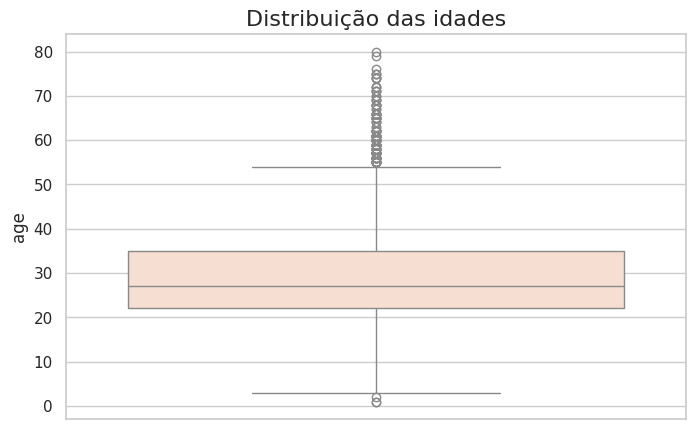

In [ ]:

plt.figure(figsize=(8,5))

sns.boxplot(
    y=df_limpo["age"]
)

plt.title("Distribuição das idades")

plt.show()

In [ ]:
# Padronização dos bairros

print(

    df_limpo["neighborhood"]

    .sort_values()

    .unique()

)

['AFLITOS' 'AFOGADOS' 'AGUA FRIA' 'ALTO DO MANDU' 'ALTO JOSE BONIFACIO'
 'ALTO JOSE DO PINHO' 'ALTO SANTA TERESINHA' 'APIPUCOS' 'AREIAS' 'ARRUDA'
 'BARRO' 'BEBERIBE' 'BOA VIAGEM' 'BOA VISTA' 'BOMBA DO HEMETERIO' 'BONGI'
 'BRASILIA TEIMOSA' 'BREJO DA GUABIRABA' 'BREJO DE BEBERIBE' 'CABANGA'
 'CACOTE' 'CAJUEIRO' 'CAMPINA DO BARRETO' 'CAMPO GRANDE' 'CASA AMARELA'
 'CASA FORTE' 'CAXANGA' 'CIDADE UNIVERSITARIA' 'COELHOS' 'COHAB'
 'COQUEIRAL' 'CORDEIRO' 'CORREGO DO JENIPAPO' 'CURADO' 'DERBY'
 'DOIS IRMAOS' 'DOIS UNIDOS' 'ENCRUZILHADA' 'ENGENHO DO MEIO' 'ESPINHEIRO'
 'ESTANCIA' 'FUNDAO' 'GRACAS' 'GUABIRABA' 'HIPODROMO' 'IBURA'
 'ILHA DO LEITE' 'ILHA DO RETIRO' 'ILHA JOANA BEZERRA' 'IMBIRIBEIRA'
 'IPSEP' 'IPUTINGA' 'JARDIM SAO PAULO' 'JIQUIA' 'JORDAO' 'LINHA DO TIRO'
 'MACAXEIRA' 'MADALENA' 'MANGABEIRA' 'MANGUEIRA' 'MONTEIRO'
 'MORRO DA CONCEICAO' 'MUSTARDINHA' 'NI' 'NOVA DESCOBERTA' 'PARNAMIRIM'
 'PASSARINHO' 'PEIXINHOS' 'PINA' 'POCO DA PANELA' 'PORTO DA MADEIRA'
 'PRADO' 'RECIFE' 'ROSARINHO'

## Resultado da Limpeza

Após as verificações realizadas nesta etapa, a base encontra-se preparada para o tratamento das inconsistências identificadas.

As decisões adotadas serão documentadas na próxima seção, garantindo transparência e reprodutibilidade do processo de preparação dos dados.

# 5. Qualidade dos Dados: Investigação do Campo de Horário

Durante a análise exploratória inicial foi identificado um comportamento incomum na distribuição das ocorrências por horário.

Observou-se que aproximadamente **64%** dos registros estavam concentrados exatamente às **21h**, indicando um possível valor padrão utilizado durante o processo de registro da ocorrência.

Antes de utilizar essa variável para análises temporais, torna-se necessário investigar sua qualidade para evitar interpretações incorretas.

Nesta etapa será realizada uma avaliação da distribuição do horário e será criada uma variável indicando quais registros possuem horário considerado confiável para análises temporais.

In [ ]:

hora_distribuicao = (

    df_limpo["data"]

    .dt.hour

    .value_counts()

    .sort_index()

)

hora_distribuicao

,count
data,
0,58
1,38
2,31
3,16
4,27
5,26
6,42
7,83
8,48


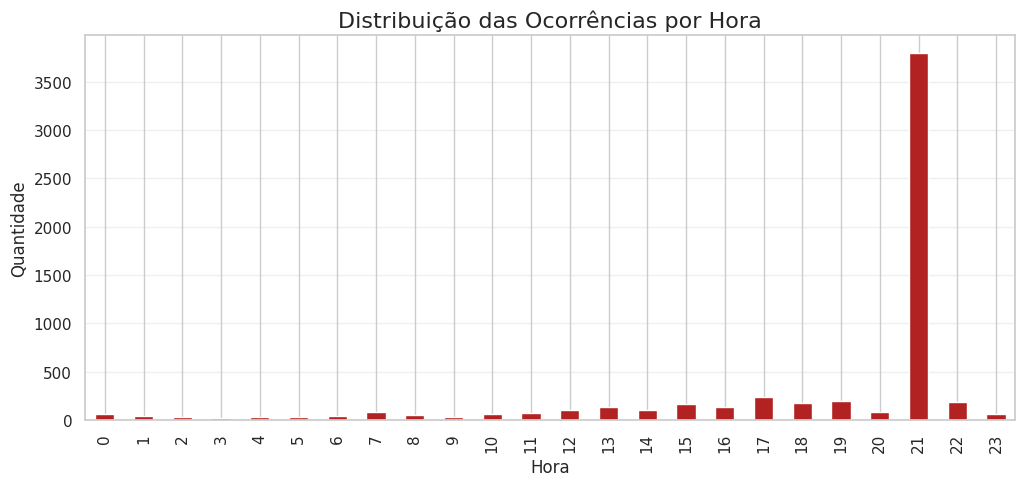

In [ ]:
plt.figure(figsize=(12,5))

hora_distribuicao.plot(

    kind="bar",

    color="firebrick"

)

plt.title("Distribuição das Ocorrências por Hora")

plt.xlabel("Hora")

plt.ylabel("Quantidade")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Avaliação

A concentração extremamente elevada de registros às **21 horas** indica que esse valor provavelmente representa um horário padrão utilizado pelo sistema de origem quando o horário real da ocorrência não é informado.

Dessa forma, considerar todos esses registros como ocorrências reais às 21h produziria uma interpretação incorreta da dinâmica temporal da violência.

Optou-se, portanto, por manter esses registros na base de dados, mas excluí-los apenas das análises especificamente relacionadas ao horário.

In [ ]:

df_limpo["hora"] = df_limpo["data"].dt.hour

df_limpo["hora_estimada"] = (

    df_limpo["hora"] == 21

)

df_limpo["hora_valida"] = (

    df_limpo["hora"] != 21

)

In [ ]:
df_limpo[

    [

        "data",

        "hora",

        "hora_estimada",

        "hora_valida"

    ]

].head()

,data,hora,hora_estimada,hora_valida
0,2018-04-01 19:00:00,19,False,True
1,2018-04-01 19:00:00,19,False,True
2,2018-04-02 21:00:00,21,True,False
3,2018-04-02 21:00:00,21,True,False
4,2018-04-02 21:00:00,21,True,False


In [ ]:
print("Horários considerados válidos:")

print(

    df_limpo["hora_valida"]

    .value_counts()

)

Horários considerados válidos:
hora_valida
False    3797
True     2092
Name: count, dtype: int64


## Decisão Metodológica

O campo de horário foi preservado integralmente na base de dados.

Entretanto, todas as análises temporais referentes ao horário da ocorrência utilizarão exclusivamente os registros classificados como **hora_valida = True**.

Essa abordagem evita perda de informações importantes e reduz o risco de interpretações enviesadas decorrentes de um possível horário padrão de registro.

# 6. Tratamento dos Dados

Após a etapa de limpeza foram definidas as estratégias de tratamento para cada inconsistência identificada.

Todas as decisões adotadas são documentadas para garantir transparência, reprodutibilidade e rastreabilidade do processo de preparação dos dados.

## Decisões de Tratamento

Com base nas verificações realizadas durante a etapa de limpeza, foram adotadas as seguintes decisões:

- Datas inválidas são convertidas para `NaT`, preservando o registro original e permitindo que análises temporais ignorem apenas os casos inconsistentes.

- Idades inferiores a 0 anos ou superiores a 110 anos são consideradas inválidas e substituídas por valores ausentes (`NaN`).

- Registros cujo horário corresponde exatamente a **21:00:00** são tratados como **horário estimado** (valor padrão do sistema). Esses registros permanecem na base principal, porém recebem uma coluna auxiliar (`hora_valida`) para evitar que análises temporais utilizem horários potencialmente artificiais.

- Categorias `"NÃO IDENTIFICADO"` em `race` e `genre` são mantidas na base (não removidas), mas destacadas separadamente nas análises demográficas, já que representam subnotificação e não um grupo demográfico real.

In [ ]:
def tratar_datas(df, coluna_data="data"):
    """
    Converte a coluna de datas para datetime.
    Datas inválidas tornam-se NaT.
    """

    df = df.copy()

    df[coluna_data] = pd.to_datetime(
        df[coluna_data],
        format="%d/%m/%Y, %H:%M:%S",
        errors="coerce"
    )

    return df


def tratar_idades(df, coluna="age"):
    """
    Idades menores que 0 ou maiores que 110
    são consideradas inválidas.
    """

    df = df.copy()

    df.loc[
        (df[coluna] < 0) |
        (df[coluna] > 110),
        coluna
    ] = np.nan

    return df


def tratar_hora_estimada(df, coluna_data="data"):
    """
    Marca registros cujo horário é o valor padrão do sistema
    (21:00:00) e cria uma coluna de hora 'válida' (NaN nesses
    casos) para uso em análises que dependem da hora exata.
    """

    df = df.copy()

    df["hora_estimada"] = (

        (df[coluna_data].dt.hour == 21) &
        (df[coluna_data].dt.minute == 0) &
        (df[coluna_data].dt.second == 0)

    )

    df["hora_valida"] = (
        df[coluna_data]
        .dt.hour
        .astype("float")
    )

    df.loc[
        df["hora_estimada"],
        "hora_valida"
    ] = np.nan

    return df


def relatorio_nulos(df):
    """
    Exibe relatório de valores ausentes.
    """

    relatorio = (

        df.isnull()

        .sum()

        .sort_values(ascending=False)

        .to_frame("Valores Ausentes")

    )

    relatorio["Percentual (%)"] = (

        relatorio["Valores Ausentes"]

        / len(df)

        * 100

    ).round(2)

    return relatorio

In [ ]:
#aplicando o tratamento
df_limpo = tratar_datas(df_limpo)

df_limpo = tratar_idades(df_limpo)

df_limpo = tratar_hora_estimada(df_limpo)

print(
    f"Registros com hora estimada "
    f"(excluídos da análise de horário): "
    f"{df_limpo['hora_estimada'].sum()}"
)

relatorio_nulos(df_limpo).head(15)

Registros com hora estimada (excluídos da análise de horário): 3769


,Valores Ausentes,Percentual (%)
complementary_reason,5889,100.00
partie,5889,100.00
hora_valida,3769,64.00
age,1806,30.67
city,0,0.00
address,0,0.00
region,0,0.00
state,0,0.00
id,0,0.00
latitude,0,0.00


### Resultado do tratamento

Após o tratamento, a base encontra-se preparada para a criação de novas variáveis temporais e para a realização das análises estatísticas.

Nenhuma informação relevante foi removida da base principal — apenas sinalizada — garantindo que os indicadores representem fielmente os registros disponíveis.

# 7. Engenharia de Atributos

Nesta etapa são criadas novas variáveis derivadas da coluna de data e hora.

Essas variáveis facilitam análises temporais e também servem como atributos na clusterização mais adiante.

As variáveis derivadas de **hora do dia** (`hora`, `periodo`) usam a coluna `hora_valida`, que já exclui os registros com horário padrão identificados na Seção 5.

In [ ]:
def criar_features_temporais(df):

    df = df.copy()

    month_map = {

        1: "JANEIRO",
        2: "FEVEREIRO",
        3: "MARÇO",
        4: "ABRIL",
        5: "MAIO",
        6: "JUNHO",
        7: "JULHO",
        8: "AGOSTO",
        9: "SETEMBRO",
        10: "OUTUBRO",
        11: "NOVEMBRO",
        12: "DEZEMBRO"

    }


    day_map = {

        "Monday": "SEGUNDA-FEIRA",
        "Tuesday": "TERÇA-FEIRA",
        "Wednesday": "QUARTA-FEIRA",
        "Thursday": "QUINTA-FEIRA",
        "Friday": "SEXTA-FEIRA",
        "Saturday": "SÁBADO",
        "Sunday": "DOMINGO"

    }


    df["ano"] = df["data"].dt.year

    df["mes"] = df["data"].dt.month

    df["nome_mes"] = df["data"].dt.month.map(month_map)

    df["dia"] = df["data"].dt.day

    df["dia_semana"] = (

        df["data"]

        .dt.day_name()

        .map(day_map)

    )

    df["trimestre"] = (

        df["data"]

        .dt.quarter

    )

    df["fim_semana"] = (

        df["dia_semana"]

        .isin(

            [

                "SÁBADO",

                "DOMINGO"

            ]

        )

    )


    df["hora"] = df["hora_valida"]

    def periodo(hora):

        if pd.isna(hora):

            return np.nan

        if hora < 6:

            return "MADRUGADA"

        elif hora < 12:

            return "MANHÃ"

        elif hora < 18:

            return "TARDE"

        else:

            return "NOITE"

    df["periodo"] = (

        df["hora"]

        .apply(periodo)

    )

    return df

In [ ]:

df_analise = criar_features_temporais(df_limpo)

### Observação

A base `df_analise` será utilizada em todas as análises exploratórias do projeto.

A base `df_limpo` permanece preservada para futuras consultas e tratamentos adicionais.

# 8. Estatística Descritiva

Antes da Análise Exploratória dos Dados (EDA), é importante compreender estatisticamente a distribuição das principais variáveis da base.

Nesta etapa serão analisadas medidas de tendência central, dispersão e distribuição, permitindo compreender o perfil geral dos registros antes da construção das visualizações e dos modelos analíticos.

In [ ]:
def resumo_estatistico(df):


    print("ESTATÍSTICAS DESCRITIVAS")


    display(df.describe())


def estatisticas_idade(df):

    idade = df["age"].dropna()

    print(f"Média.............: {idade.mean():.2f}")
    print(f"Mediana...........: {idade.median():.2f}")
    print(f"Moda..............: {idade.mode()[0]}")
    print(f"Desvio padrão.....: {idade.std():.2f}")
    print(f"Variância.........: {idade.var():.2f}")

In [ ]:
resumo_estatistico(
    df_analise[
        [
            "age",
            "latitude",
            "longitude"
        ]
    ]
)

estatisticas_idade(df_analise)

ESTATÍSTICAS DESCRITIVAS


,age,latitude,longitude
count,4083.000000,5889.000000,5889.000000
mean,29.221406,-8.054849,-34.921455
std,10.779422,0.041900,0.024245
min,1.000000,-8.152800,-34.993871
25%,22.000000,-8.085702,-34.937197
50%,27.000000,-8.057944,-34.921666
75%,35.000000,-8.018023,-34.903381
max,80.000000,-7.932411,-34.869131


Média.............: 29.22
Mediana...........: 27.00
Moda..............: 22.0
Desvio padrão.....: 10.78
Variância.........: 116.20


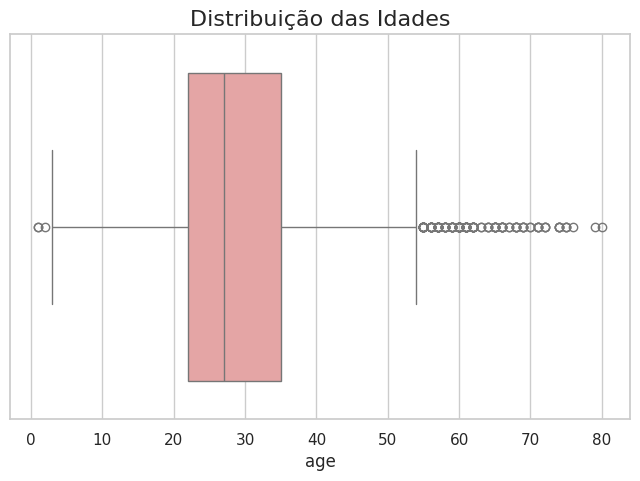

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_analise["age"],
    color="#EF9A9A"
)

plt.title("Distribuição das Idades")

plt.show()

In [ ]:
idade_bairro = (

    df_analise

    .groupby("neighborhood")["age"]

    .mean()

    .sort_values(ascending=False)

)

idade_bairro.head(10)

,age
neighborhood,
DERBY,50.600000
TORREAO,50.000000
CASA FORTE,43.333333
MONTEIRO,37.666667
ZUMBI,37.111111
ENGENHO DO MEIO,37.105263
ALTO DO MANDU,36.571429
CASA AMARELA,36.181818
SANTANA,35.333333


In [ ]:
idade_ocorrencia = (

    df_analise

    .groupby("main_reason")["age"]

    .mean()

    .sort_values(ascending=False)

)

idade_ocorrencia

,age
main_reason,
SUICÍDIO,49.333333
TENTATIVA/ROUBO A BANCO,34.500000
BRIGA,33.920792
TENTATIVA/ROUBO,32.350000
OPERAÇÃO POLICIAL,30.615385
ATAQUE A CIVIS,29.571429
HOMICIDIO/TENTATIVA,29.005279
NÃO IDENTIFICADO,28.640000
TIROS A ESMO,27.500000


In [ ]:
distribuicao_hora = (

    df_analise["hora"]

    .value_counts()

    .sort_index()

)

print(

    f"Registros com hora válida para análise: "

    f"{int(distribuicao_hora.sum())} de {len(df_analise)}"

)

distribuicao_hora

Registros com hora válida para análise: 2120 de 5889


,count
hora,
0.0,58
1.0,38
2.0,31
3.0,16
4.0,27
5.0,26
6.0,42
7.0,83
8.0,48


In [ ]:
ordem = [

    "SEGUNDA-FEIRA",

    "TERÇA-FEIRA",

    "QUARTA-FEIRA",

    "QUINTA-FEIRA",

    "SEXTA-FEIRA",

    "SÁBADO",

    "DOMINGO"

]

distribuicao_semana = (

    df_analise["dia_semana"]

    .value_counts()

    .reindex(ordem)

)

distribuicao_semana

,count
dia_semana,
SEGUNDA-FEIRA,801
TERÇA-FEIRA,872
QUARTA-FEIRA,827
QUINTA-FEIRA,817
SEXTA-FEIRA,514
SÁBADO,1147
DOMINGO,911


### Principais Observações

Nesta etapa foram identificadas as principais características estatísticas da base de dados.

As medidas de tendência central permitiram compreender o perfil médio das vítimas, enquanto as distribuições temporais — já corrigidas quanto ao artefato do horário padrão identificado anteriormente — auxiliam na identificação dos dias e períodos com maior concentração de ocorrências.

Essas informações servem como base para a Análise Exploratória de Dados (EDA), apresentada na próxima seção.

# 9. Análise Exploratória de Dados (EDA)

A Análise Exploratória de Dados (EDA) tem como objetivo compreender padrões, tendências e relações presentes nos registros de ocorrências.

Nesta etapa serão exploradas as dimensões espacial, temporal e demográfica dos dados, buscando gerar insights que possam apoiar futuras tomadas de decisão em segurança pública.

## 9.1 Distribuição das Ocorrências por Bairro

Nesta análise são identificados os bairros com maior número de registros, permitindo localizar regiões prioritárias para ações preventivas.

In [ ]:
def grafico_bairro(df, top=10):

    bairros = (

        df["neighborhood"]

        .value_counts()

        .head(top)

        .sort_values()

    )

    fig, ax = plt.subplots(figsize=(12,7))

    bars = ax.barh(

        bairros.index,

        bairros.values,

        color="#D32F2F"

    )

    ax.set_title(

        f"Top {top} bairros com maior número de ocorrências",

        fontsize=16,

        weight="bold"

    )

    ax.set_xlabel("Quantidade de ocorrências")

    for barra in bars:

        largura = barra.get_width()

        ax.text(

            largura + 2,

            barra.get_y() + barra.get_height()/2,

            f"{int(largura)}",

            va="center"

        )

    plt.tight_layout()

    plt.show()

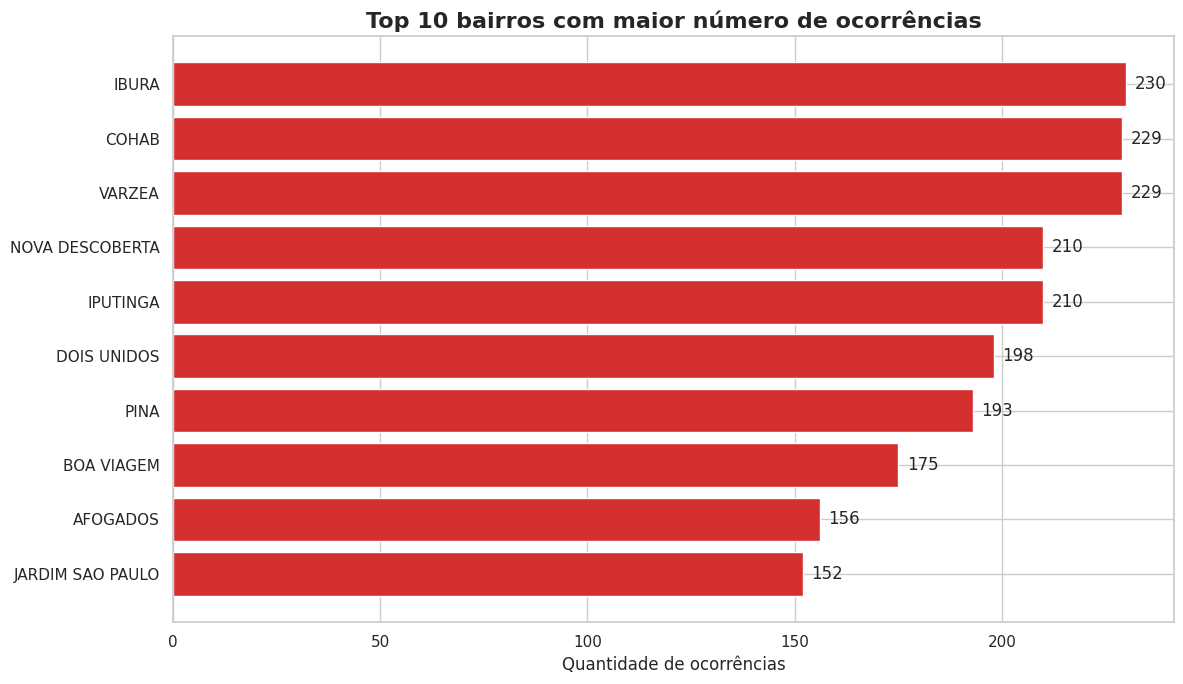

In [ ]:
grafico_bairro(df_analise)

### Insight

Os bairros com maior quantidade de registros representam áreas prioritárias para intervenções preventivas.

Essas regiões podem demandar reforço do policiamento, investimentos em infraestrutura urbana e monitoramento contínuo por meio da plataforma **Vigia Recife**.

## 9.2 Evolução Temporal das Ocorrências

Nesta etapa é analisada a evolução do número de registros ao longo do tempo,
permitindo identificar períodos de crescimento ou redução das ocorrências.

> **Nota:** 2026 aparece incompleto na base (dados até a data de extração), então a
leitura do último ano deve considerar que o total ainda não fechou o ciclo anual.

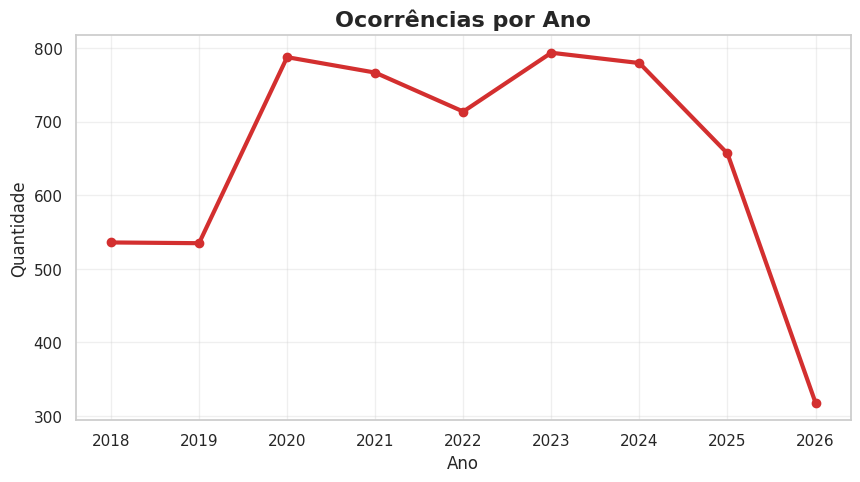

In [ ]:
def perfil_temporal(df):
    serie = df.groupby("ano").size()

    plt.figure(figsize=(10, 5))
    plt.plot(
        serie.index,
        serie.values,
        marker="o",
        linewidth=3,
        color="#D32F2F"
    )

    plt.title("Ocorrências por Ano", fontsize=16, weight="bold")
    plt.xlabel("Ano")
    plt.ylabel("Quantidade")
    plt.grid(alpha=.3)
    plt.show()

    return serie

serie_anual = perfil_temporal(df_analise)

### Insight

A análise temporal permite identificar tendências de crescimento ou redução das ocorrências ao longo dos anos, auxiliando na avaliação da efetividade de políticas públicas e estratégias de segurança.

O salto observado em 2020 e a queda nos anos seguintes merecem contextualização com eventos externos (ex.: pandemia, mudanças em políticas de segurança) antes de qualquer conclusão causal.

## 9.3 Perfil Demográfico das Vítimas

Nesta seção são analisadas características demográficas das vítimas registradas:
gênero, raça e faixa etária.

> **Atenção — qualidade dos dados:** a categoria `"NÃO IDENTIFICADO"` corresponde a **72% dos registros de raça** e a uma parcela de `genre`. Isso não deve ser interpretado como um "grupo racial predominante" — é subnotificação. Nas leituras abaixo, tratamos essa categoria separadamente para não distorcer a interpretação.

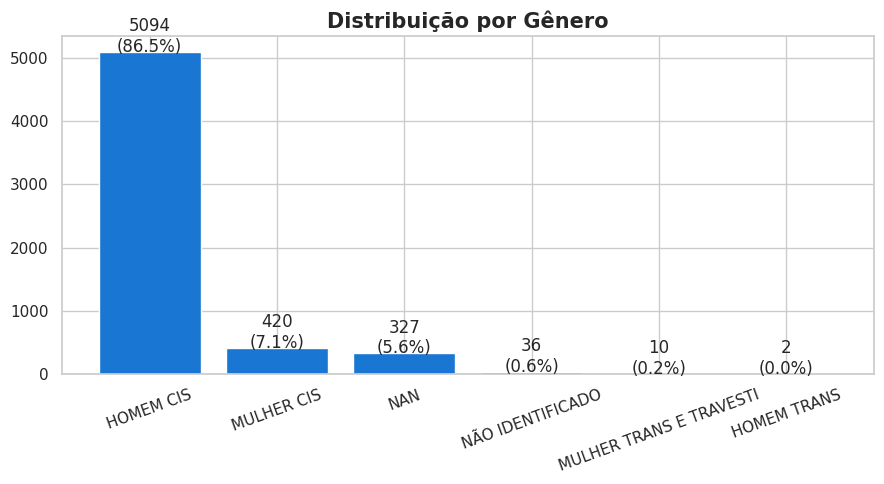

In [ ]:
def grafico_genero(df):
    dados = df["genre"].value_counts()

    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(
        dados.index,
        dados.values,
        color="#1976D2"
    )

    total = dados.sum()

    for barra in bars:
        valor = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor,
            f"{valor}\n({valor/total:.1%})",
            ha="center"
        )

    plt.title("Distribuição por Gênero", fontsize=15, weight="bold")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

grafico_genero(df_analise)

### Insight

A distribuição por gênero mostra forte predominância de vítimas do sexo masculino cis, padrão consistente com estatísticas nacionais de violência letal no Brasil, e permite direcionar políticas públicas específicas.

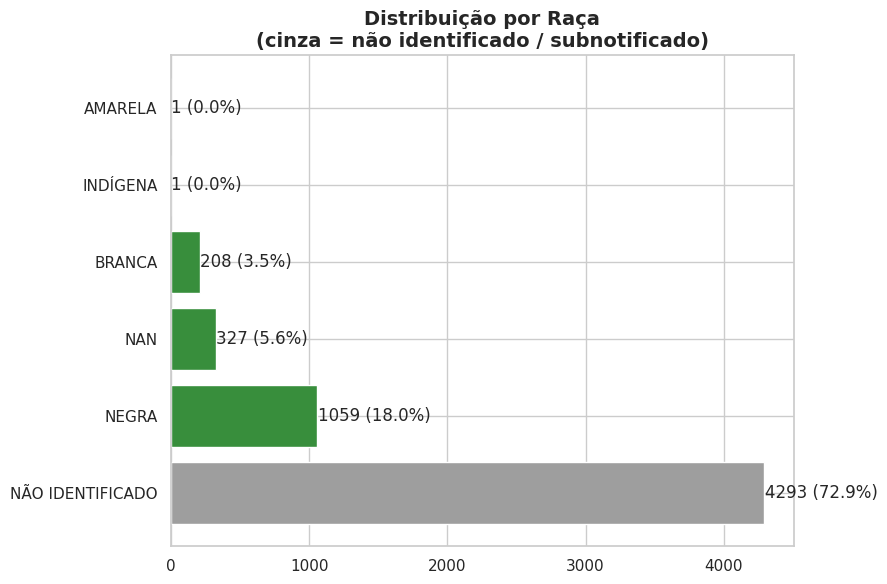

In [ ]:
def grafico_raca(df):
    dados = df["race"].fillna("NÃO INFORMADO").value_counts()

    cores = [
        "#9E9E9E" if cat == "NÃO IDENTIFICADO" else "#388E3C"
        for cat in dados.index
    ]

    fig, ax = plt.subplots(figsize=(9, 6))

    bars = ax.barh(
        dados.index,
        dados.values,
        color=cores
    )

    total = dados.sum()

    for barra in bars:
        largura = barra.get_width()
        ax.text(
            largura + 2,
            barra.get_y() + barra.get_height() / 2,
            f"{largura} ({largura/total:.1%})",
            va="center"
        )

    plt.title(
        "Distribuição por Raça\n(cinza = não identificado / subnotificado)",
        fontsize=14,
        weight="bold"
    )

    plt.tight_layout()
    plt.show()

grafico_raca(df_analise)

In [ ]:
# Distribuição de raça considerando apenas os casos em que houve identificação

raca_identificada = df_analise[
    ~df_analise["race"].isin(["NÃO IDENTIFICADO"])
    & df_analise["race"].notna()
]["race"].value_counts(normalize=True) * 100

print(
    f"Casos com raça identificada: "
    f"{len(raca_identificada) and (df_analise['race'].notna() & (df_analise['race']!='NÃO IDENTIFICADO')).sum()} "
    f"de {len(df_analise)}"
)

raca_identificada.round(1)

Casos com raça identificada: 1596 de 5889


,proportion
race,
NEGRA,66.4
NAN,20.5
BRANCA,13.0
INDÍGENA,0.1
AMARELA,0.1


### Insight

Entre os registros em que a raça **foi de fato identificada**, há sobre-representação de vítimas negras — alinhado a evidências nacionais sobre desigualdade racial na exposição à violência letal.

Ainda assim, o alto índice de subnotificação (72%) é, em si, um achado relevante: indica uma lacuna no preenchimento dos boletins de ocorrência que compromete a qualidade de políticas públicas baseadas nesse dado.

In [ ]:
def perfil_bairro(df, bairro):
    dados = df[df["neighborhood"] == bairro]

    return pd.DataFrame({
        "Bairro": [bairro],
        "Ocorrências": [len(dados)],
        "Tipo predominante": [dados["main_reason"].mode().iloc[0]],
        "Gênero predominante": [dados["genre"].mode().iloc[0]],
        "Faixa etária": [dados["ageGroup"].mode().iloc[0]],
        "Dia crítico": [
            dados["dia_semana"].mode().iloc[0]
            if dados["dia_semana"].notna().any()
            else "N/D"
        ],
    })

top5 = df_analise["neighborhood"].value_counts().head(5).index

painel = pd.concat(
    [perfil_bairro(df_analise, b) for b in top5],
    ignore_index=True
)

painel

,Bairro,Ocorrências,Tipo predominante,Gênero predominante,Faixa etária,Dia crítico
0,IBURA,230,HOMICIDIO/TENTATIVA,HOMEM CIS,ADULTO,SÁBADO
1,VARZEA,229,HOMICIDIO/TENTATIVA,HOMEM CIS,ADULTO,DOMINGO
2,COHAB,229,HOMICIDIO/TENTATIVA,HOMEM CIS,ADULTO,SÁBADO
3,IPUTINGA,210,HOMICIDIO/TENTATIVA,HOMEM CIS,ADULTO,QUINTA-FEIRA
4,NOVA DESCOBERTA,210,HOMICIDIO/TENTATIVA,HOMEM CIS,ADULTO,SÁBADO


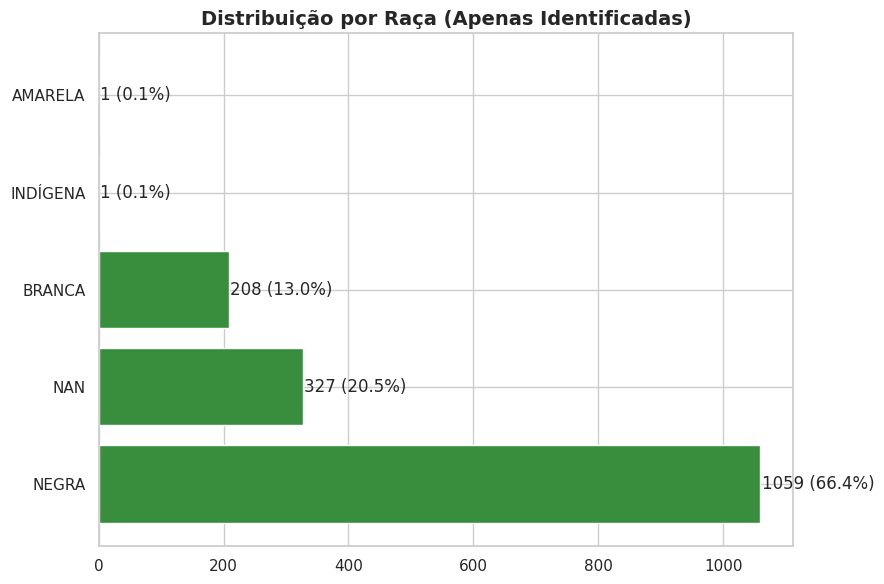

In [ ]:
def grafico_raca_apenas_identificada(df):
    # Filtrar o DataFrame para incluir apenas as raças identificadas e não nulas
    df_identificado = df[~df["race"].isin(["NÃO IDENTIFICADO"]) & df["race"].notna()]

    # Calcular a contagem de valores para as raças identificadas
    dados = df_identificado["race"].value_counts()

    if dados.empty:
        print("Não há dados de raça identificados para exibir.")
        return

    # Definir cores para o gráfico (todas verdes, já que 'NÃO IDENTIFICADO' será excluído)
    cores = ["#388E3C"] * len(dados)

    fig, ax = plt.subplots(figsize=(9, 6))

    bars = ax.barh(
        dados.index,
        dados.values,
        color=cores
    )

    total = dados.sum()

    for barra in bars:
        largura = barra.get_width()
        ax.text(
            largura + 2,
            barra.get_y() + barra.get_height() / 2,
            f"{largura} ({largura/total:.1%})",
            va="center"
        )

    plt.title(
        "Distribuição por Raça (Apenas Identificadas)",
        fontsize=14,
        weight="bold"
    )

    plt.tight_layout()
    plt.show()

grafico_raca_apenas_identificada(df_analise)

# 10. Análises Avançadas

Nesta etapa são aplicadas técnicas estatísticas e de aprendizado de máquina para identificar padrões ocultos nos dados.

## 10.1 Correlação entre Variáveis

Algoritmos estatísticos trabalham apenas com dados numéricos. Por isso, as variáveis categóricas são codificadas utilizando Label Encoding apenas para fins de análise de correlação.

> A coluna `hora` usada aqui já exclui os registros com horário padrão (Seção 5), evitando que o artefato contamine a correlação.

In [ ]:
def preparar_correlacao(df):
    dados = df.copy()

    encoder = LabelEncoder()

    colunas = [
        "neighborhood",
        "main_reason",
        "genre",
        "race"
    ]

    for coluna in colunas:
        dados[coluna] = encoder.fit_transform(
            dados[coluna].astype(str)
        )

    dados["police_action"] = dados["police_action"].astype(int)

    return dados


dados_corr = preparar_correlacao(df_analise)

correlacao = dados_corr[
    [
        "hora",
        "neighborhood",
        "main_reason",
        "police_action",
        "age"
    ]
].corr()

correlacao

,hora,neighborhood,main_reason,police_action,age
hora,1.000000,0.048995,-0.119714,0.006786,-0.051175
neighborhood,0.048995,1.000000,-0.014263,-0.016529,-0.039744
main_reason,-0.119714,-0.014263,1.000000,-0.205521,0.056825
police_action,0.006786,-0.016529,-0.205521,1.000000,-0.055433
age,-0.051175,-0.039744,0.056825,-0.055433,1.000000


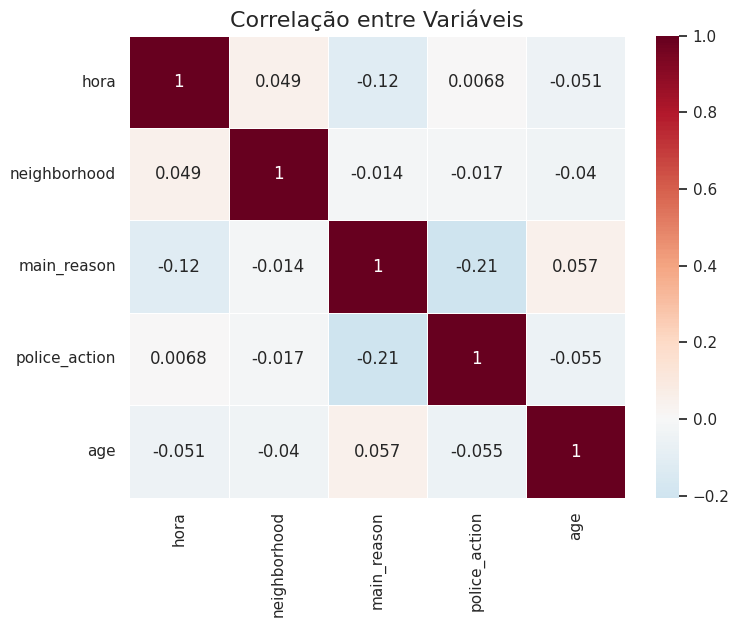

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="RdBu_r",
    center=0,
    linewidths=.5
)

plt.title("Correlação entre Variáveis")
plt.show()

### Insight

A matriz de correlação permite identificar relações lineares entre as variáveis analisadas. Correlações próximas de zero indicam baixa associação linear, enquanto valores mais elevados sugerem padrões que podem ser explorados em modelos preditivos.

Como esperado para dados majoritariamente categóricos codificados, as correlações lineares são fracas — isso é normal e não indica erro na análise.

## 10.2 Idade das Vítimas por Tipo de Ocorrência

O boxplot permite comparar a distribuição das idades para cada categoria de ocorrência.

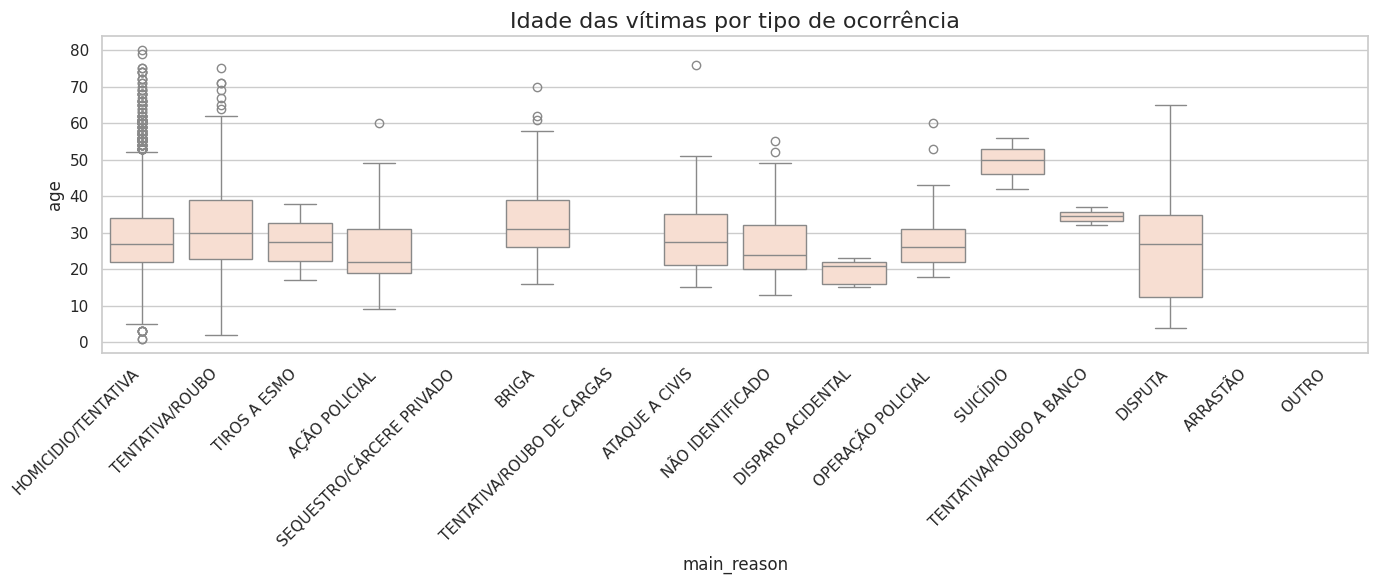

In [ ]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_analise,
    x="main_reason",
    y="age"
)

plt.xticks(rotation=45, ha="right")

plt.title("Idade das vítimas por tipo de ocorrência")

plt.tight_layout()
plt.show()

### Insight

A comparação entre os tipos de ocorrência evidencia diferenças no perfil etário das vítimas, indicando quais eventos tendem a afetar grupos de idade distintos.

## 10.3 Densidade Espacial das Ocorrências

Duas visualizações complementares: um mapa de calor interativo (Folium) e uma estimativa de densidade Kernel (KDE) estática, que mostra regiões de maior concentração de registros independentemente dos limites administrativos dos bairros.

In [ ]:
mapa = folium.Map(
    location=[-8.0476, -34.8770],
    zoom_start=12,
    tiles="cartodbpositron"
)

dados_mapa = df_limpo[
    ["latitude", "longitude"]
].dropna()

HeatMap(
    dados_mapa.values.tolist(),
    radius=10,
    blur=15,
    max_zoom=13
).add_to(mapa)

mapa

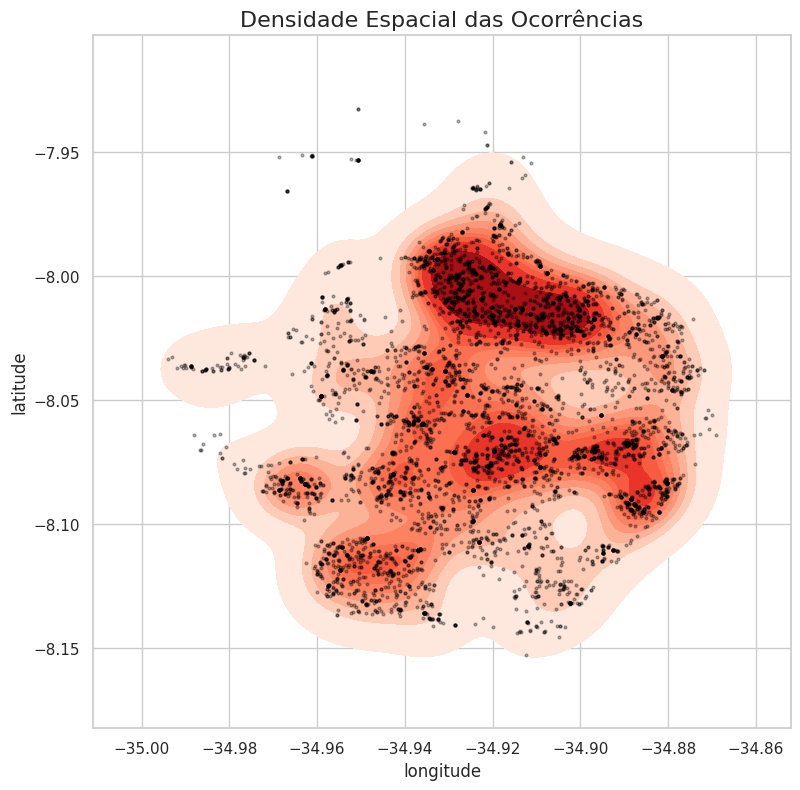

In [ ]:
plt.figure(figsize=(9, 9))

sns.kdeplot(
    data=df_analise,
    x="longitude",
    y="latitude",
    fill=True,
    cmap="Reds",
    thresh=0.02
)

plt.scatter(
    df_analise["longitude"],
    df_analise["latitude"],
    s=4,
    color="black",
    alpha=.3
)

plt.title("Densidade Espacial das Ocorrências")
plt.show()

### Insight

As regiões com maior intensidade de cor representam áreas de elevada concentração de ocorrências, podendo indicar hotspots urbanos prioritários para monitoramento.

## 10.4 Clusterização de Bairros

**Melhoria em relação à versão anterior:** o agrupamento original usava apenas 3 variáveis agregadas por bairro (contagem de ocorrências, idade média e % de ação policial), o que fazia os clusters ficarem dominados pelo volume total de ocorrências — dois bairros com perfis de violência muito diferentes, mas volume parecido, caíam no mesmo grupo.

Aqui o perfil de cada bairro é enriquecido com:

- proporção de ocorrências por período do dia (madrugada/manhã/tarde/noite);
- proporção dos principais tipos de ocorrência;
- idade média das vítimas;
- percentual de ação policial;
- percentual de casos em fins de semana.

Isso faz os clusters refletirem **padrões de comportamento**, não apenas volume.

In [ ]:
# Base agregada por bairro

agg_volume = df_analise.groupby("neighborhood").agg(
    ocorrencias=("id", "count"),
    idade_media=("age", "mean"),
    acao_policial=("police_action", "mean"),
    pct_fim_semana=("fim_semana", "mean"),
)

# Proporção por período do dia

prop_periodo = (
    pd.crosstab(
        df_analise["neighborhood"],
        df_analise["periodo"],
        normalize="index"
    )
    .add_prefix("periodo_")
)

# Proporção dos 5 tipos de ocorrência mais comuns
# (demais agrupados em "OUTROS")

top_tipos = df_analise["main_reason"].value_counts().head(5).index

df_tipo = df_analise.copy()

df_tipo["main_reason_agrupado"] = df_tipo["main_reason"].where(
    df_tipo["main_reason"].isin(top_tipos),
    "OUTROS"
)

prop_tipo = (
    pd.crosstab(
        df_tipo["neighborhood"],
        df_tipo["main_reason_agrupado"],
        normalize="index"
    )
    .add_prefix("tipo_")
)

cluster = (
    agg_volume
    .join(prop_periodo, how="left")
    .join(prop_tipo, how="left")
)

# Mantém apenas bairros com volume mínimo de ocorrências,
# para evitar que bairros com 1–2 registros distorçam o agrupamento.

MIN_OCORRENCIAS = 10

cluster = cluster[
    cluster["ocorrencias"] >= MIN_OCORRENCIAS
]

cluster = cluster.fillna(
    cluster.mean(numeric_only=True)
)

print(f"Bairros incluídos na clusterização: {len(cluster)}")

cluster.head()

Bairros incluídos na clusterização: 74


,ocorrencias,idade_media,acao_policial,pct_fim_semana,periodo_MADRUGADA,periodo_MANHÃ,periodo_NOITE,periodo_TARDE,tipo_AÇÃO POLICIAL,tipo_BRIGA,tipo_HOMICIDIO/TENTATIVA,tipo_NÃO IDENTIFICADO,tipo_OUTROS,tipo_TENTATIVA/ROUBO
neighborhood,,,,,,,,,,,,,,
AFOGADOS,156,28.631579,0.070513,0.314103,0.200000,0.175000,0.175000,0.450000,0.057692,0.012821,0.858974,0.012821,0.019231,0.038462
AGUA FRIA,148,30.439655,0.013514,0.358108,0.136364,0.090909,0.431818,0.340909,0.006757,0.013514,0.932432,0.000000,0.027027,0.020270
ALTO DO MANDU,16,36.571429,0.062500,0.250000,0.111111,0.000000,0.555556,0.333333,0.062500,0.187500,0.562500,0.000000,0.187500,0.000000
ALTO JOSE BONIFACIO,67,28.372549,0.044776,0.388060,0.062500,0.187500,0.312500,0.437500,0.029851,0.000000,0.925373,0.000000,0.014925,0.029851
ALTO JOSE DO PINHO,48,26.410256,0.041667,0.333333,0.000000,0.100000,0.300000,0.600000,0.041667,0.020833,0.812500,0.020833,0.062500,0.041667


In [ ]:
K_ESCOLHIDO = 4

modelo = KMeans(
    n_clusters=K_ESCOLHIDO,
    random_state=42,
    n_init=10
)

cluster["cluster"] = modelo.fit_predict(X)

cluster[
    [
        "ocorrencias",
        "idade_media",
        "acao_policial",
        "cluster"
    ]
].sort_values("cluster").head(10)

,ocorrencias,idade_media,acao_policial,cluster
neighborhood,,,,
AGUA FRIA,148,30.439655,0.013514,0
ALTO JOSE BONIFACIO,67,28.372549,0.044776,0
ALTO SANTA TERESINHA,43,30.812500,0.046512,0
ALTO JOSE DO PINHO,48,26.410256,0.041667,0
AREIAS,90,31.953846,0.044444,0
BRASILIA TEIMOSA,96,28.972603,0.010417,0
BOMBA DO HEMETERIO,76,29.677419,0.013158,0
BARRO,110,28.400000,0.072727,0
COELHOS,78,28.354167,0.012821,0


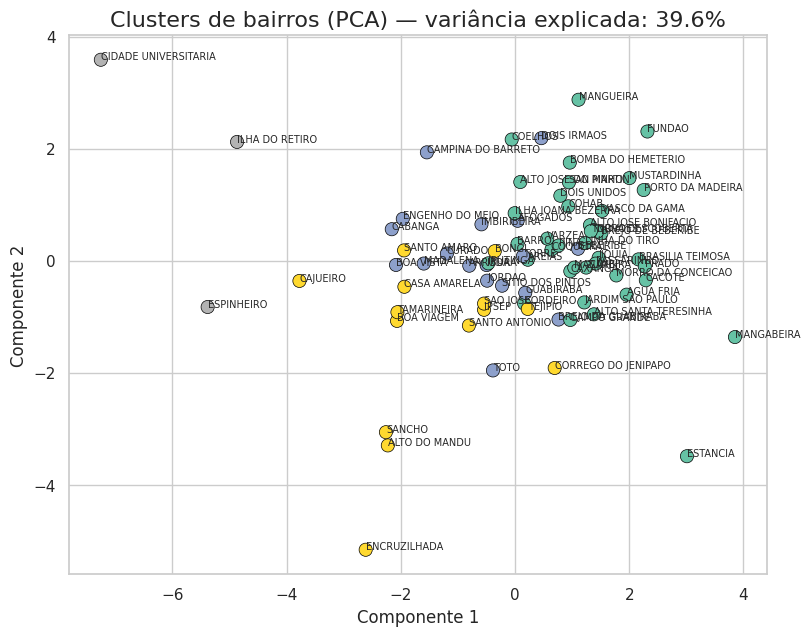

In [ ]:
pca = PCA(n_components=2)

componentes = pca.fit_transform(X)

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    componentes[:, 0],
    componentes[:, 1],
    c=cluster["cluster"],
    cmap="Set2",
    s=90,
    edgecolor="black",
    linewidth=.5
)

for i, bairro in enumerate(cluster.index):
    plt.text(
        componentes[i, 0],
        componentes[i, 1],
        bairro,
        fontsize=7
    )

plt.title(
    f"Clusters de bairros (PCA) — variância explicada: {pca.explained_variance_ratio_.sum():.1%}"
)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.show()

In [ ]:
# Perfil médio de cada cluster
# Ajuda a nomear e interpretar os grupos.

resumo_clusters = (
    cluster.groupby("cluster")[
        [
            "ocorrencias",
            "idade_media",
            "acao_policial",
            "pct_fim_semana"
        ]
    ]
    .mean()
    .round(2)
)

resumo_clusters

,ocorrencias,idade_media,acao_policial,pct_fim_semana
cluster,,,,
0,93.59,28.79,0.03,0.37
1,72.94,29.85,0.09,0.38
2,55.07,31.47,0.07,0.26
3,21.00,28.34,0.24,0.29


### Insight

Com atributos comportamentais (período do dia, tipo de ocorrência, ação policial), os clusters deixam de refletir apenas "bairros com mais ou menos ocorrências" e passam a distinguir **perfis de violência**: por exemplo, bairros com maior concentração em madrugada versus bairros com maior concentração em horário comercial, ou bairros com maior/menor resposta policial proporcional.

Isso é mais acionável para desenho de políticas públicas segmentadas do que um ranking simples por volume.

## 10.5 Séries Temporais e Tendência

Análise da evolução mensal das ocorrências, com média móvel e teste estatístico de tendência (regressão linear).

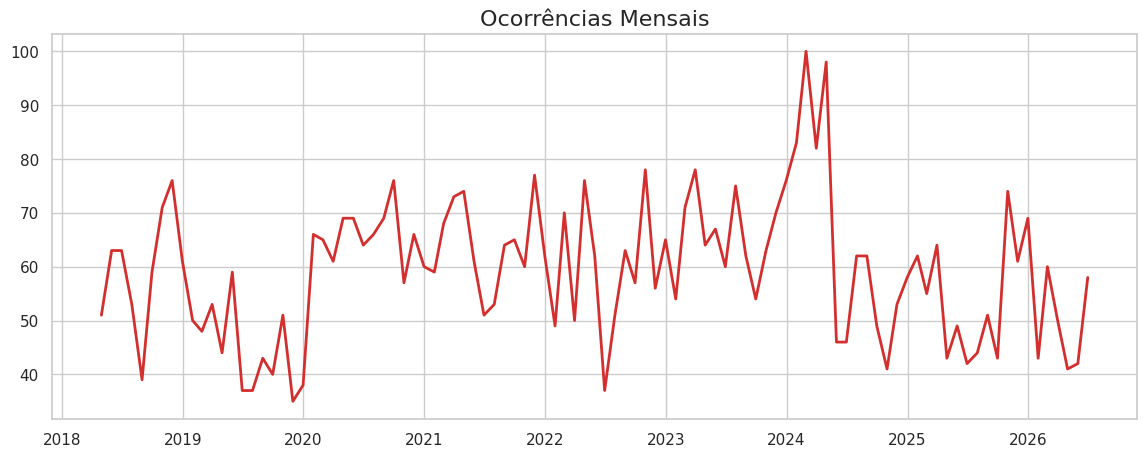

In [ ]:
serie_mensal = (
    df_analise
    .set_index("data")
    .resample("ME")
    .size()
)

# Remove o último mês se estiver incompleto
# (mês corrente na extração dos dados)

if len(serie_mensal) > 0:
    ultimo_mes_completo = (
        pd.Timestamp.today()
        .normalize()
        .replace(day=1)
        - pd.Timedelta(days=1)
    )

    serie_mensal_completa = serie_mensal[
        serie_mensal.index <= ultimo_mes_completo
    ]
else:
    serie_mensal_completa = serie_mensal

plt.figure(figsize=(14, 5))

plt.plot(
    serie_mensal_completa,
    linewidth=2,
    color="#D32F2F"
)

plt.title("Ocorrências Mensais")

plt.show()

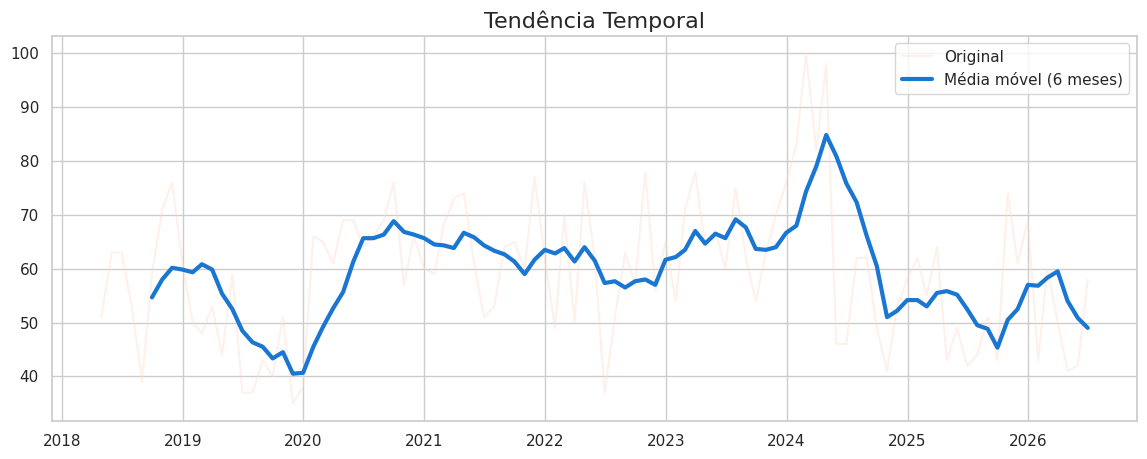

In [ ]:
media_movel = serie_mensal_completa.rolling(6).mean()

plt.figure(figsize=(14, 5))

plt.plot(
    serie_mensal_completa,
    alpha=.4,
    label="Original"
)

plt.plot(
    media_movel,
    linewidth=3,
    label="Média móvel (6 meses)",
    color="#1976D2"
)

plt.legend()

plt.title("Tendência Temporal")

plt.show()

A média móvel suaviza oscilações mensais e facilita a identificação de tendências de longo prazo nas ocorrências registradas.

In [ ]:
x = np.arange(len(serie_mensal_completa))

resultado = linregress(
    x,
    serie_mensal_completa.values
)

print(f"Inclinação: {resultado.slope:.2f}")
print(f"P-valor: {resultado.pvalue:.5f}")

if resultado.pvalue < 0.05:
    direcao = (
        "crescimento"
        if resultado.slope > 0
        else "queda"
    )

    print(
        f"Há tendência estatisticamente significativa de {direcao}."
    )
else:
    print(
        "Não foi identificada tendência estatisticamente significativa (p >= 0.05)."
    )

Inclinação: 0.01
P-valor: 0.74975
Não foi identificada tendência estatisticamente significativa (p >= 0.05).


# 11. Ação Policial

Apenas **5-6% das ocorrências registram ação policial**.

Esse percentual, isoladamente, diz pouco — o valor de negócio está em entender **onde e quando** essa resposta se concentra ou falta.

In [ ]:
acao_por_bairro = (
    df_analise
    .groupby("neighborhood")["police_action"]
    .agg(
        ocorrencias="count",
        pct_acao="mean"
    )
    .query("ocorrencias >= 20")
    .sort_values(
        "pct_acao",
        ascending=False
    )
)

acao_por_bairro["pct_acao"] = (
    acao_por_bairro["pct_acao"] * 100
).round(1)

print(
    "Top 10 bairros com MAIOR % de ação policial (mín. 20 ocorrências):"
)

display(acao_por_bairro.head(10))

print(
    "\nTop 10 bairros com MENOR % de ação policial (mín. 20 ocorrências):"
)

display(
    acao_por_bairro.tail(10).sort_values("pct_acao")
)

Top 10 bairros com MAIOR % de ação policial (mín. 20 ocorrências):


,ocorrencias,pct_acao
neighborhood,,
ILHA DO RETIRO,33,24.2
CAMPINA DO BARRETO,39,15.4
BOA VISTA,61,11.5
IBURA,230,11.3
JORDAO,82,11.0
CASA AMARELA,55,10.9
ENGENHO DO MEIO,28,10.7
IPSEP,61,9.8
SANTO AMARO,92,9.8



Top 10 bairros com MENOR % de ação policial (mín. 20 ocorrências):


,ocorrencias,pct_acao
neighborhood,,
ESTANCIA,21,0.0
BEBERIBE,30,0.0
TEJIPIO,33,0.0
PRADO,49,0.0
BRASILIA TEIMOSA,96,1.0
COELHOS,78,1.3
MUSTARDINHA,75,1.3
BOMBA DO HEMETERIO,76,1.3
AGUA FRIA,148,1.4


In [ ]:
acao_por_tipo = (
    df_analise
    .groupby("main_reason")["police_action"]
    .agg(
        ocorrencias="count",
        pct_acao="mean"
    )
    .query("ocorrencias >= 10")
    .sort_values(
        "pct_acao",
        ascending=False
    )
)

acao_por_tipo["pct_acao"] = (
    acao_por_tipo["pct_acao"] * 100
).round(1)

acao_por_tipo

,ocorrencias,pct_acao
main_reason,,
AÇÃO POLICIAL,216,100.0
OPERAÇÃO POLICIAL,35,100.0
TENTATIVA/ROUBO,401,13.5
DISPUTA,22,4.5
BRIGA,169,1.2
HOMICIDIO/TENTATIVA,4755,0.1
ATAQUE A CIVIS,62,0.0
NÃO IDENTIFICADO,161,0.0
TIROS A ESMO,31,0.0


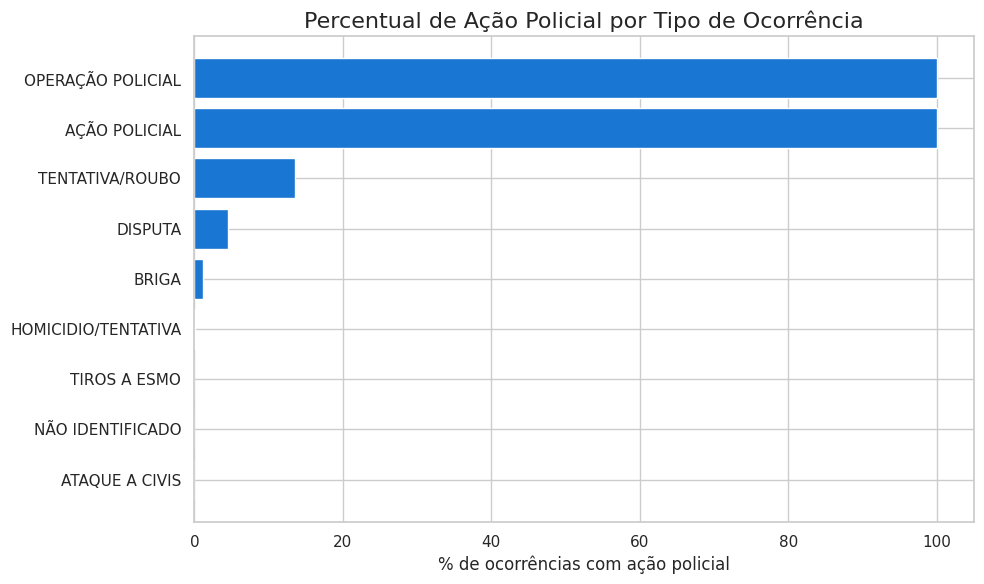

In [ ]:
plt.figure(figsize=(10, 6))

dados_plot = acao_por_tipo.sort_values("pct_acao")

plt.barh(
    dados_plot.index,
    dados_plot["pct_acao"],
    color="#1976D2"
)

plt.xlabel("% de ocorrências com ação policial")

plt.title(
    "Percentual de Ação Policial por Tipo de Ocorrência"
)

plt.tight_layout()

plt.show()

### Insight

A resposta policial não é uniforme entre bairros nem entre tipos de ocorrência.

Bairros com baixo percentual de ação policial e alto volume de ocorrências são candidatos naturais a reforço operacional; a variação por tipo de ocorrência ajuda a entender em quais contextos a presença policial já é mais recorrente (ex.: operações policiais, por definição, têm ação policial registrada quase sempre) versus em quais ela é rara mesmo diante de eventos graves.